# Rockall Trough transport

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.RT_functions as rtf
import src.features.RT_data as rtd
import src.features.RT_transport as rtt
import src.set_paths as sps
import src.RT_parameters as rtp
import src.features.RT_EOF_functions as rt_eof
import src.features.RT_visualise as rtv

/home/sa05af/.conda/envs/af_python3_12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sa05af/Projects/Rockall_Trough_Transports/notebooks/../src/features/RT_transport.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
import dask
import datetime
import gsw
import scipy
import scipy.io
import cmocean as cm
import seaborn as sns
import numpy as np
import pandas as pd
import seawater as sw
import scipy.signal as signal
import palettable.colorbrewer as cb
import xarray as xr
from pathlib import Path
from scipy.signal import butter, filtfilt
from xhistogram.xarray import histogram as xhist
%matplotlib inline
from matplotlib import pyplot as plt

## set some plot parameters

In [3]:
sns.set_theme(context='notebook',
              style="whitegrid",
              palette="colorblind",
              rc={"axes.axisbelow": False}
             )
plt.rcParams['lines.linewidth'] = 1.4 

### Set in- and output path

In [4]:
date_str_start = '201407'
date_str_end = '202407'
fn_out_version = 'v1'
script_name = f"05_afox_Rockall_Trough_transports_{date_str_start[:-2]}_{date_str_end[:-2]}_{fn_out_version}"

# output figures
fig_out_path = (sps.local_fig_dir/f"{script_name}")
Path(fig_out_path).mkdir(parents=True, exist_ok=True)

In [5]:
# output data
data_out_path = (sps.local_data_dir/f"{script_name}")
Path(data_out_path).mkdir(parents=True, exist_ok=True)

data_out_path_od = (sps.RT_data_path/f"{script_name}")
Path(data_out_path_od).mkdir(parents=True, exist_ok=True)

fn_base_Q = "Rockall_Trough_transport_time_series"
fn_base_grid = "Rockall_Trough_transport_3D_time_series"
fn_base_EK = "Rockall_Trough_Ekman_transport_time_series"
fn_base_profile = "Rockall_Trough_transport_profile_time_series"

file_name_out_Q = f"{fn_base_Q}_{date_str_start}_{date_str_end}_{fn_out_version}.nc"
file_name_out_grid = f"{fn_base_grid}_{date_str_start}_{date_str_end}_{fn_out_version}.nc"
file_name_out_Ek = f"{fn_base_EK}_{date_str_start}_{date_str_end}_{fn_out_version}.nc"
file_name_out_profile = f"{fn_base_profile}_{date_str_start}_{date_str_end}_{fn_out_version}.nc"


In [6]:
file_name_out_profile

'Rockall_Trough_transport_profile_time_series_201407_202407_v1.nc'

In [7]:
# intput data
fn_in_version = 'v1'
fn_base_grid = "Rockall_Trough_mooring_gridded_TSUV"
fn_base_stack = "Rockall_Trough_mooring_stacked_TSUV"

RT_mooring_fn = f"{fn_base_grid}_{date_str_start}_{date_str_end}_{fn_in_version}.nc"
file_name_in_stack = f"{fn_base_stack}_{date_str_start}_{date_str_end}_{fn_in_version}.nc"

## Load Data and prepare for calculations

In [8]:
sps.raw_data_dir

PosixPath('/home/sa05af/Projects/Rockall_Trough_Transports/notebooks/../data/raw')

In [9]:
# Rockall Trough mooring location
ds_RT_loc=rtd.load_RT_loc()

# stacked RT mooing data
ds_RT_stacked = xr.open_dataset((sps.RT_mooring_data_path/file_name_in_stack))

# load gridded Rockall Trough mooring data
ds_RT = xr.open_dataset((sps.RT_mooring_data_path/RT_mooring_fn))

In [10]:
ds_RT_loc

<xarray.Dataset> Size: 112B
Dimensions:     ()
Data variables: (12/14)
    lon_RTWB1   float64 8B -12.7
    lat_RTWB1   float64 8B 57.47
    lon_RTWB2   float64 8B -12.32
    lat_RTWB2   float64 8B 57.47
    lon_RTWB    float64 8B -12.51
    lat_RTWB    float64 8B 57.47
    ...          ...
    lon_RTADCP  float64 8B -9.341
    lat_RTADCP  float64 8B 57.1
    lon_RTWS    float64 8B -13.03
    lat_RTWS    float64 8B 57.47
    lon_RTES    float64 8B -9.193
    lat_RTES    float64 8B 57.1

In [11]:
# Extrapolate top and linearly interpolate over gaps
ds_RT = rtf.prep_mooring_data_for_transport_calc(ds_RT,ds_RT_loc)

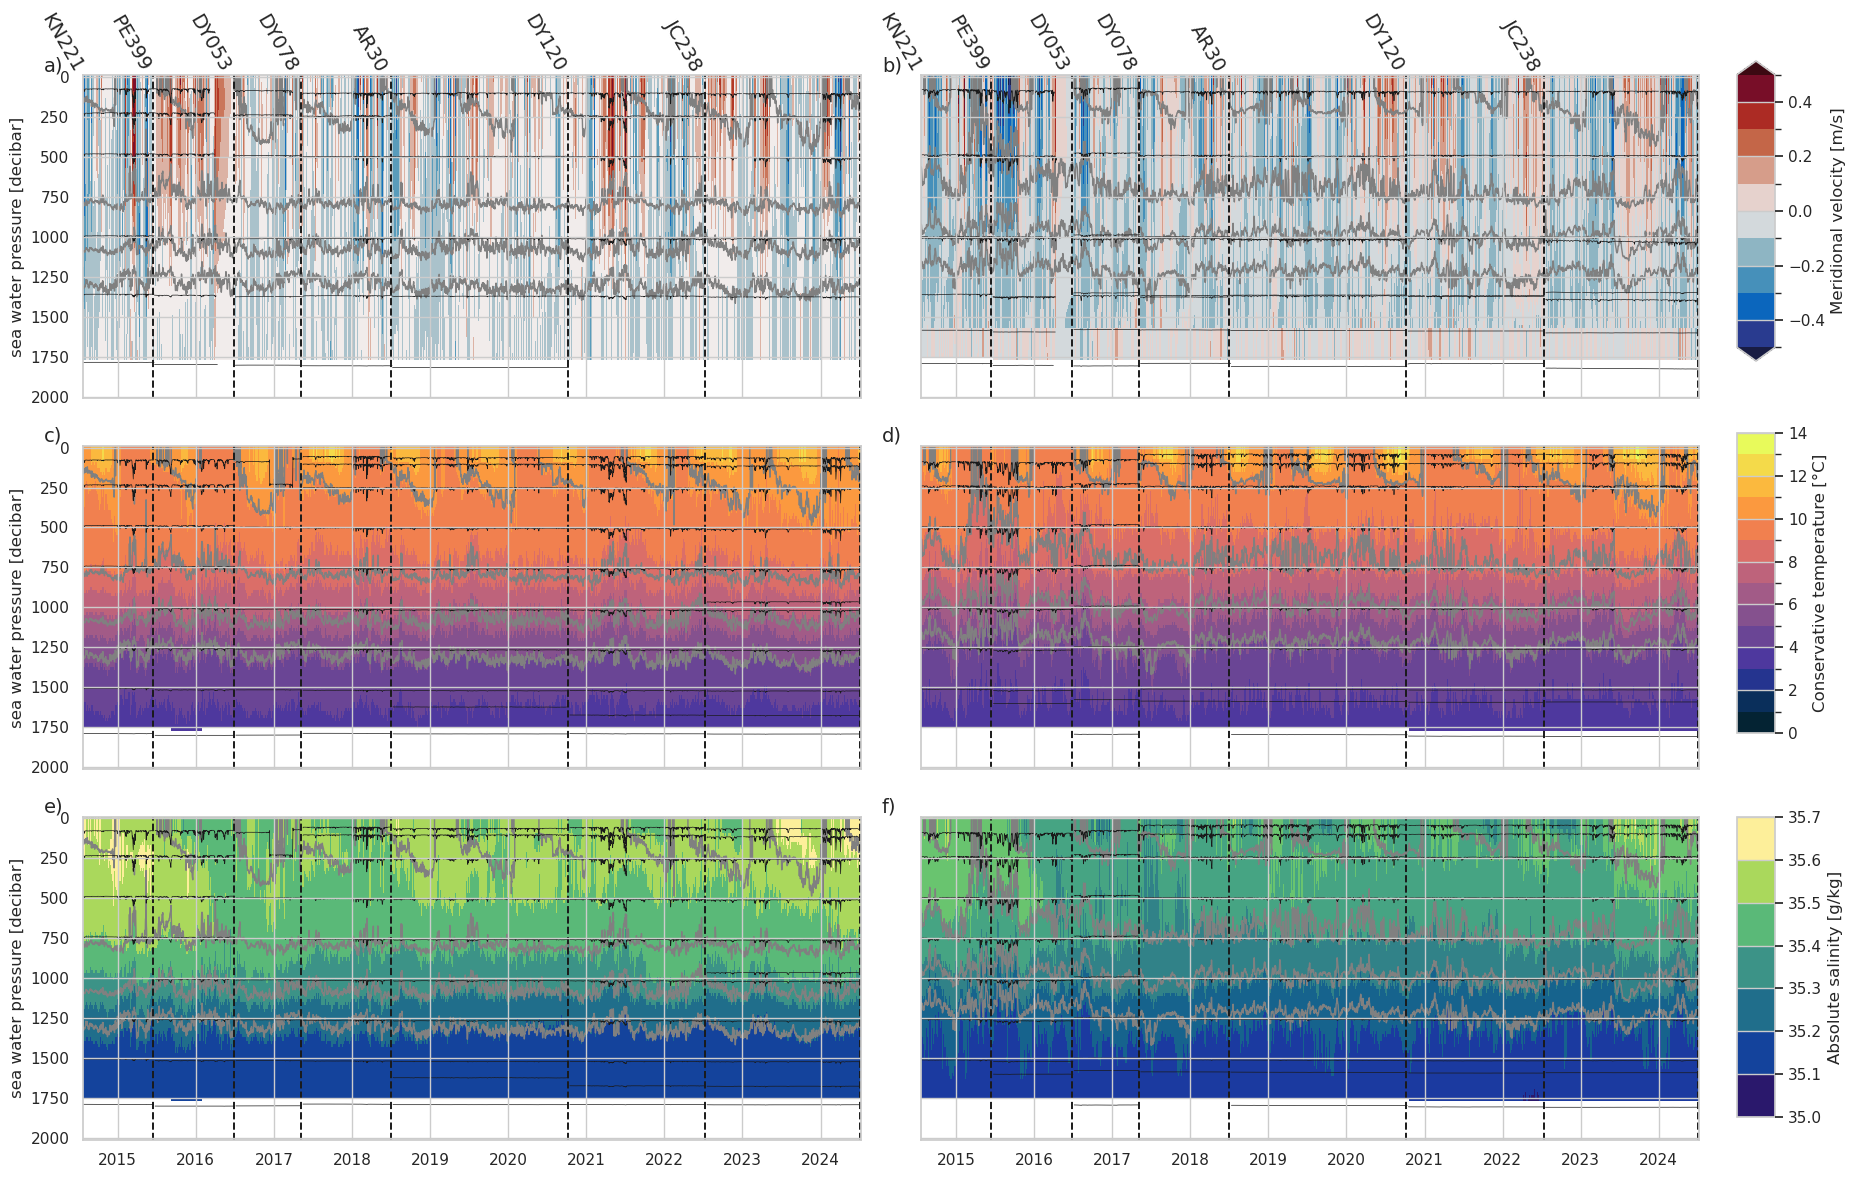

In [12]:
fig = rtv.plot_moorings_paper(ds_RT,ds_RT_stacked)
# fig.savefig(fig_out_path/f'RT_EB_WB_gridded_timeseries_{date_str_start[:-2]}_{date_str_end[:-2]}.png',bbox_inches='tight')

In [13]:
ds_RT

<xarray.Dataset> Size: 65MB
Dimensions:   (TIME: 7279, depth: 101)
Coordinates:
  * TIME      (TIME) datetime64[ns] 58kB 2014-07-21T12:00:00 ... 2024-07-07T1...
    PRES      (depth) float64 808B 0.0 20.19 40.38 60.57 ... 1.988e+03 nan nan
  * depth     (depth) float32 404B 0.0 20.0 40.0 ... 1.96e+03 1.98e+03 2e+03
Data variables:
    TG_EAST   (TIME, depth) float64 6MB 10.34 10.34 10.34 10.34 ... nan nan nan
    TG_WEST   (TIME, depth) float64 6MB 10.22 10.22 10.22 10.22 ... nan nan nan
    SG_EAST   (TIME, depth) float64 6MB 35.58 35.58 35.58 35.58 ... nan nan nan
    SG_WEST   (TIME, depth) float64 6MB 35.56 35.56 35.56 35.56 ... nan nan nan
    U_WEST_1  (TIME, depth) float64 6MB -6.113 -6.012 -5.91 ... nan nan nan
    V_WEST_1  (TIME, depth) float64 6MB -1.635 -1.867 -2.099 ... nan nan nan
    U_WEST_2  (TIME, depth) float64 6MB nan nan nan nan nan ... nan nan nan nan
    V_WEST_2  (TIME, depth) float64 6MB nan nan nan nan nan ... nan nan nan nan
    U_EAST    (TIME, depth) float64 6MB -1.015 -1.004 -0.993 ... nan nan nan
    V_EAST    (TIME, depth) float64 6MB -7.281 -7.315 -7.349 ... nan nan nan
    v_RTWB    (TIME, depth) float64 6MB -1.635 -1.867 -2.099 ... nan nan nan
    v_mask    (TIME, depth) bool 735kB True True True True ... False False False
Attributes: (12/24)
    title:                         CLASS Rockall Trough mooring data 07/2014-...
    institution:                   Scottish Association for Marine Science, S...
    history:                       Delayed time processed quality controlled
    id:                            Rockall_Trough_mooring_gridded_TSUV_201407...
    source:                        subsurface mooring
    project:                       Climate Linked Atlantic Sector Science
    ...                            ...
    citation:                      These data were collected and made freely ...
    acknowledgement:               Funding source: the UK Natural Environment...
    date_created:                  2025-01-30T19:53:33Z
    date_modified:                 2025-01-30T19:53:33Z
    processing_level:              
    QC_indicator:

In [14]:
# Load  GEBCO bathymetry
ds_GEBCO = xr.open_dataset((sps.GEBCO_data_path/sps.GEBCO_fn))
ds_GEBCO = ds_GEBCO.where(ds_GEBCO.elevation<=0)

# load GLORYS model data
ds_GLORYS = rtd.load_glorys('RTADCP',ds_RT.TIME.min(),ds_RT.TIME.max())

# load ERA5
ds_ERA5 = xr.open_dataset((sps.ERA5_data_path/sps.ERA5_fn))

Data is in GLORYS reanlysis and interim period


In [66]:
ds_ERA5


<xarray.Dataset> Size: 188kB
Dimensions:     (valid_time: 132, latitude: 7, longitude: 25)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 1kB 2014-01-01T06:00:00 ... 2024-...
  * latitude    (latitude) float64 56B 58.0 57.75 57.5 57.25 57.0 56.75 56.5
  * longitude   (longitude) float64 200B -14.0 -13.75 -13.5 ... -8.5 -8.25 -8.0
    expver      (valid_time) <U4 2kB ...
Data variables:
    metss       (valid_time, latitude, longitude) float32 92kB ...
    mntss       (valid_time, latitude, longitude) float32 92kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

# Calculations

## Horizontal and vertical grid parameters

In [15]:
RT_hor_grid = rtt.create_horizontal_grid('v0')

In [16]:
RT_hor_grid

<xarray.Dataset> Size: 7kB
Dimensions:   (lon_WW: 100, lon_MB: 99, lon_EW: 100, lon_MB_1: 100)
Coordinates:
  * lon_WW    (lon_WW) float64 800B -13.03 -13.03 -13.02 ... -12.52 -12.51
  * lon_MB_1  (lon_MB_1) float64 800B -12.51 -12.48 -12.45 ... -9.59 -9.561
  * lon_EW    (lon_EW) float64 800B -9.561 -9.557 -9.553 ... -9.2 -9.197 -9.193
Dimensions without coordinates: lon_MB
Data variables:
    dx_WW     (lon_WW) float64 800B 157.4 314.9 314.9 ... 314.9 314.9 157.4
    dx_MB     (lon_MB) float64 792B 1.83e+03 1.83e+03 ... 1.847e+03 1.847e+03
    dx_EW     (lon_EW) float64 800B 112.1 224.3 224.3 ... 224.3 224.3 112.1
    lat_WW    (lon_WW) float64 800B 57.47 57.47 57.47 ... 57.47 57.47 57.47
    lat_MB    (lon_MB_1) float64 800B 57.47 57.47 57.46 ... 57.11 57.1 57.1
    lat_EW    (lon_EW) float64 800B 57.1 57.1 57.1 57.1 ... 57.1 57.1 57.1 57.1

In [17]:
# Get dz (top/bottom cells are ~10m thick, cells are ~20m thick elsewhere)
dz = rtt.get_dz(ds_RT.depth)
ds_RT['dz']=xr.DataArray(dz,dims='depth')

## Midbasin transport based on no motion at 1760 dbar

CPU times: user 7.44 s, sys: 50.1 ms, total: 7.49 s
Wall time: 7.49 s


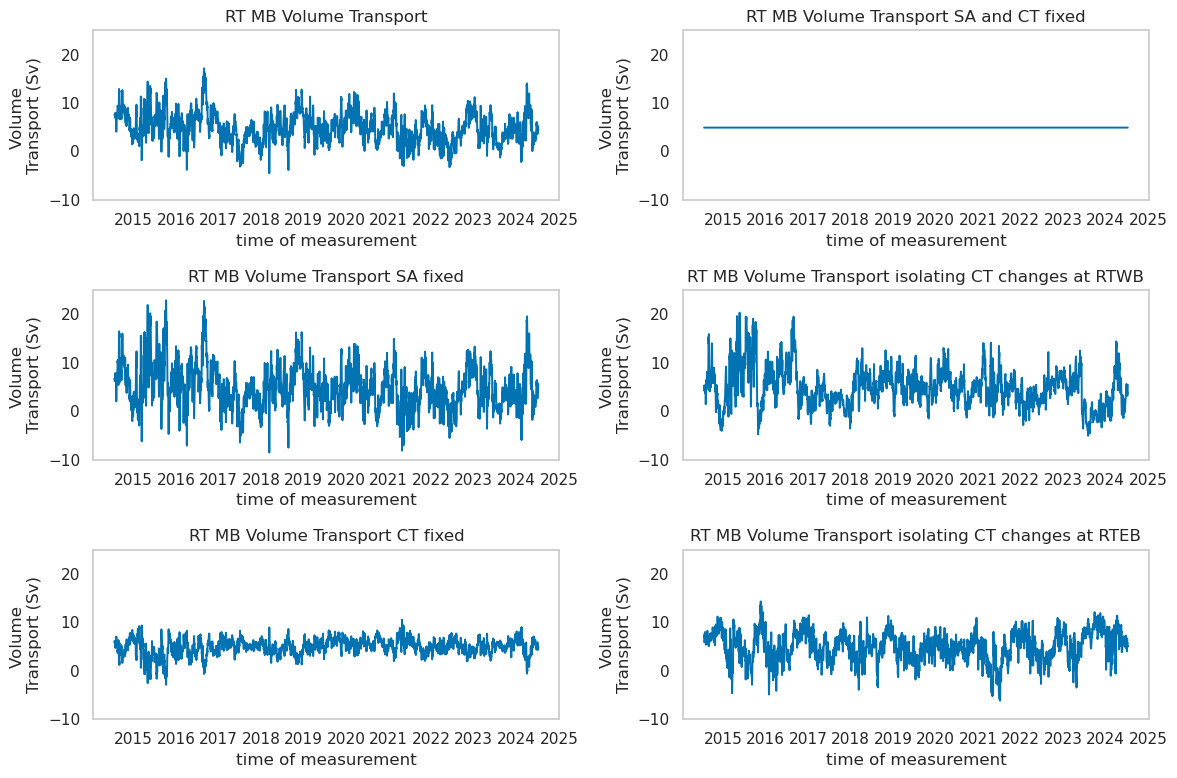

In [18]:
%%time
RT_Q_MB,q_MB = rtt.calc_MB_transport(ds_RT,ds_RT_loc,sens_analysis=True,check_plots=True)

In [19]:
%%time
# create MB matrix, fine horizontal grid, new and not in Fraser et al. (2022)
ds_RT_MB_grid = rtt.calc_MB_3D_sections(ds_RT,ds_RT_loc,RT_hor_grid)

CPU times: user 1min 26s, sys: 4.81 s, total: 1min 31s
Wall time: 1min 31s


## Western wedge transport

CPU times: user 2min 4s, sys: 1min 44s, total: 3min 49s
Wall time: 3min 49s


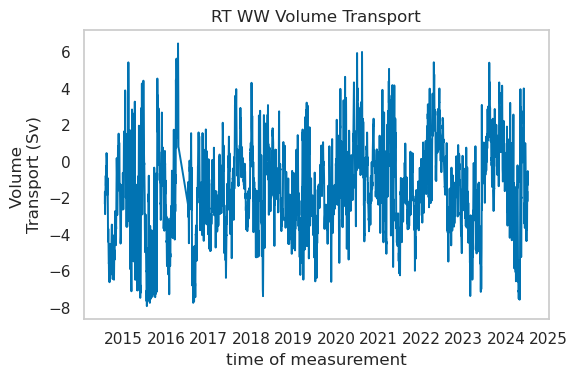

In [20]:
%%time
Q_WW, ds_RT_WW_grid = rtt.calc_WW_transport(ds_RT,ds_RT_loc,RT_hor_grid,ds_GEBCO)

In [21]:
RT_hor_grid

<xarray.Dataset> Size: 7kB
Dimensions:   (lon_WW: 100, lon_MB: 99, lon_EW: 100, lon_MB_1: 100)
Coordinates:
  * lon_WW    (lon_WW) float64 800B -13.03 -13.03 -13.02 ... -12.52 -12.51
  * lon_MB_1  (lon_MB_1) float64 800B -12.51 -12.48 -12.45 ... -9.59 -9.561
  * lon_EW    (lon_EW) float64 800B -9.561 -9.557 -9.553 ... -9.2 -9.197 -9.193
Dimensions without coordinates: lon_MB
Data variables:
    dx_WW     (lon_WW) float64 800B 157.4 314.9 314.9 ... 314.9 314.9 157.4
    dx_MB     (lon_MB) float64 792B 1.83e+03 1.83e+03 ... 1.847e+03 1.847e+03
    dx_EW     (lon_EW) float64 800B 112.1 224.3 224.3 ... 224.3 224.3 112.1
    lat_WW    (lon_WW) float64 800B 57.47 57.47 57.47 ... 57.47 57.47 57.47
    lat_MB    (lon_MB_1) float64 800B 57.47 57.47 57.46 ... 57.11 57.1 57.1
    lat_EW    (lon_EW) float64 800B 57.1 57.1 57.1 57.1 ... 57.1 57.1 57.1 57.1

In [22]:
ds_RT_loc

<xarray.Dataset> Size: 112B
Dimensions:     ()
Data variables: (12/14)
    lon_RTWB1   float64 8B -12.7
    lat_RTWB1   float64 8B 57.47
    lon_RTWB2   float64 8B -12.32
    lat_RTWB2   float64 8B 57.47
    lon_RTWB    float64 8B -12.51
    lat_RTWB    float64 8B 57.47
    ...          ...
    lon_RTADCP  float64 8B -9.341
    lat_RTADCP  float64 8B 57.1
    lon_RTWS    float64 8B -13.03
    lat_RTWS    float64 8B 57.47
    lon_RTES    float64 8B -9.193
    lat_RTES    float64 8B 57.1

## Eastern wedge

CPU times: user 14.4 s, sys: 6.08 s, total: 20.5 s
Wall time: 21.1 s


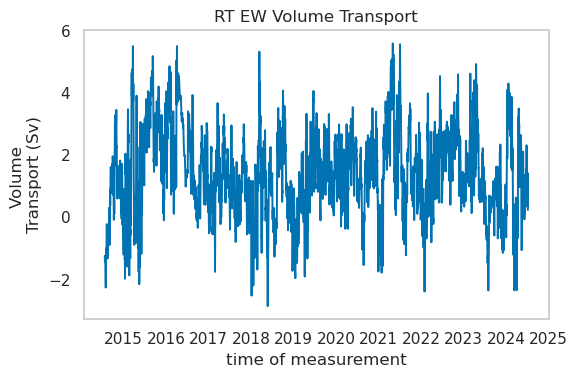

In [23]:
%%time
Q_EW, ds_RT_EW_grid = rtt.calc_EW_F22_transport(ds_RT,ds_RT_loc,RT_hor_grid,ds_GEBCO,ds_GLORYS)

## Ekman transport - monthly mean data

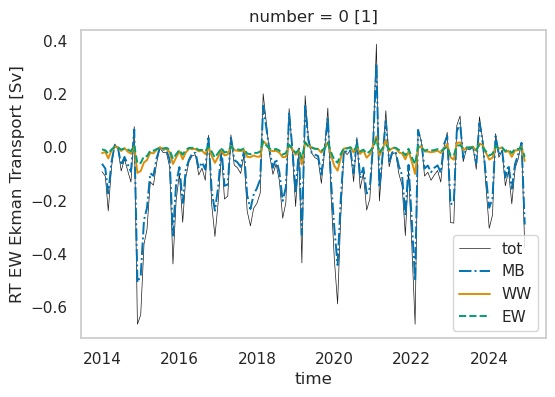

In [24]:
RT_Q_Ek = rtt.calc_Ekman_transport(ds_ERA5, RT_hor_grid,ds_RT_loc,check_plots=True)

## Heat and Freshwater transports

In [25]:
# Get SA and CT fields - interpolate for midbasin
ds_RT['SG_MB'] = (ds_RT.SG_WEST + ds_RT.SG_EAST)/2
ds_RT['TG_MB'] = (ds_RT.TG_WEST + ds_RT.TG_EAST)/2

In [26]:
ds_Q_MB,ds_q_MB = rtt.calc_transports(RT_Q_MB.RT_Q_MB,q_MB.drop_vars(['lat','lon']),
                                  ds_RT.TG_MB,ds_RT.SG_MB,
                                  ['depth'],'MB')
ds_Q_EW,ds_q_EW = rtt.calc_transports(Q_EW,ds_RT_EW_grid.q,ds_RT.TG_EAST,ds_RT.SG_EAST,
                                  ['depth','lon'],'EW')
ds_Q_WW,ds_q_WW = rtt.calc_transports(Q_WW,ds_RT_WW_grid.q,ds_RT.TG_WEST,ds_RT.SG_WEST,
                                  ['depth','lon'],'WW')

In [27]:
ds_RT_EW_grid = rtt.add_da_to_ds(ds_RT_EW_grid,ds_q_EW)
ds_RT_WW_grid = rtt.add_da_to_ds(ds_RT_WW_grid,ds_q_WW)

In [28]:
ds_Q_tot = rtt.combine_sections_tot_transp(ds_Q_WW,ds_Q_MB,ds_Q_EW)

In [29]:
# finer grid MB
# Compute transports in each cell
ds_Q_MB_grid,ds_q_MB_grid = rtt.calc_transports(RT_Q_MB.RT_Q_MB,ds_RT_MB_grid.q,
                                  ds_RT.TG_MB,ds_RT.SG_MB,
                                  ['depth','lon'],'MB')

ds_RT_MB_grid = rtt.add_da_to_ds(ds_RT_MB_grid,ds_q_MB_grid)

In [30]:
# Isolate changes in velocity, mean tracer 
ds_Q1_MB,ds_q1_MB = rtt.calc_transports(RT_Q_MB.RT_Q_MB,q_MB.drop_vars(['lat','lon']),
                ds_RT.TG_MB.mean('TIME'),ds_RT.SG_MB.mean('TIME'),
                ['depth'],'MB_TSfix')
ds_Q1_EW,ds_q1_EW = rtt.calc_transports(Q_EW,ds_RT_EW_grid.q,
                ds_RT.TG_EAST.mean('TIME'),ds_RT.SG_EAST.mean('TIME'),
                ['depth','lon'],'EW_TSfix')
ds_Q1_WW,ds_q1_WW = rtt.calc_transports(Q_WW,ds_RT_WW_grid.q,
                ds_RT.TG_WEST.mean('TIME'),ds_RT.SG_WEST.mean('TIME'),
                ['depth','lon'],'WW_TSfix')

# Isolate changes in tracer, mean velocity
ds_Q2_MB,ds_q2_MB = rtt.calc_transports(RT_Q_MB.RT_Q_MB.mean('TIME'),q_MB.mean('TIME').drop_vars(['lat','lon']),
                ds_RT.TG_MB,ds_RT.SG_MB,
                ['depth'],'MB_qfix')
ds_Q2_EW,ds_q2_EW = rtt.calc_transports(Q_EW.mean('TIME'),ds_RT_EW_grid.q.mean('TIME'),
                ds_RT.TG_EAST,ds_RT.SG_EAST,
                ['depth','lon'],'EW_qfix')
ds_Q2_WW,ds_q2_WW = rtt.calc_transports(Q_WW.mean('TIME'),ds_RT_WW_grid.q.mean('TIME'),
                ds_RT.TG_WEST,ds_RT.SG_WEST,
                ['depth','lon'],'WW_qfix')

In [31]:
ds_q_EW

<xarray.Dataset> Size: 2GB
Dimensions:  (lon: 100, depth: 101, TIME: 7279)
Coordinates:
  * lon      (lon) float64 800B -9.561 -9.557 -9.553 ... -9.2 -9.197 -9.193
    PRES     (depth) float64 808B 0.0 20.19 40.38 60.57 ... 1.988e+03 nan nan
  * depth    (depth) float32 404B 0.0 20.0 40.0 60.0 ... 1.96e+03 1.98e+03 2e+03
  * TIME     (TIME) datetime64[ns] 58kB 2014-07-21T12:00:00 ... 2024-07-07T12...
    lat      (lon) float64 800B 57.1 57.1 57.1 57.1 57.1 ... 57.1 57.1 57.1 57.1
    dx       (lon) float64 800B 112.1 224.3 224.3 224.3 ... 224.3 224.3 112.1
    mask     (lon, depth, TIME) bool 74MB dask.array<chunksize=(100, 101, 7279), meta=np.ndarray>
Data variables:
    q        (lon, depth, TIME) float64 588MB dask.array<chunksize=(100, 101, 7279), meta=np.ndarray>
    qh       (lon, depth, TIME) float64 588MB dask.array<chunksize=(100, 101, 7279), meta=np.ndarray>
    qf       (lon, depth, TIME) float64 588MB dask.array<chunksize=(100, 101, 7279), meta=np.ndarray>
    qS       (lon, depth, TIME) float64 588MB dask.array<chunksize=(100, 101, 7279), meta=np.ndarray>
Attributes:
    description:  Volume, heat, freshwater and salt tranport per grid cell fo...

## Apply low pass filter

Q has length 1, no filter applied
Q has length 1, no filter applied
Q has length 1, no filter applied


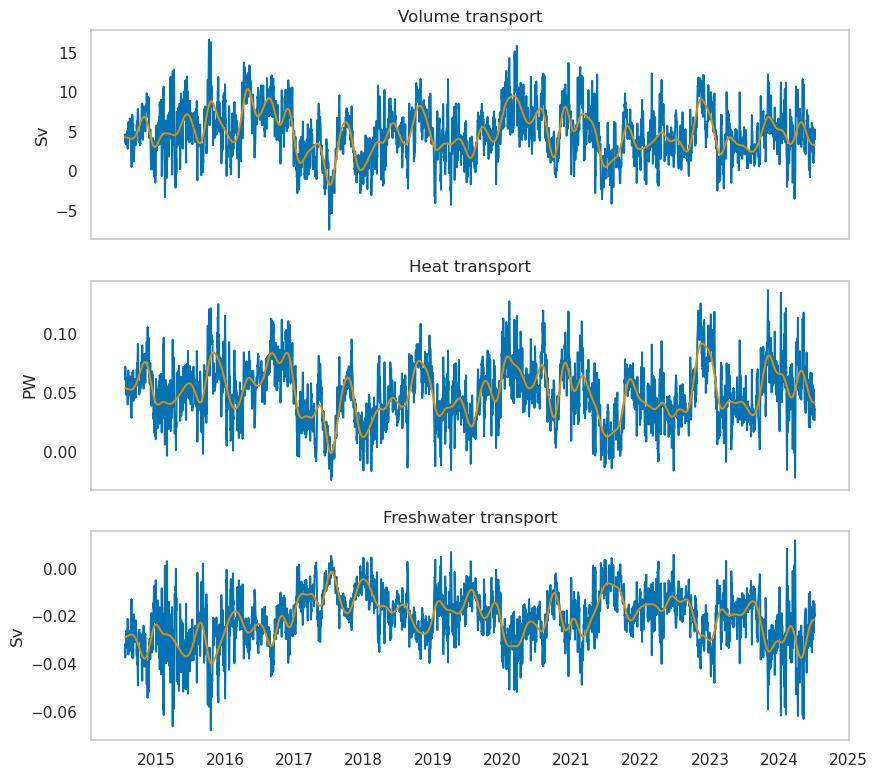

In [32]:
#low pass filter
dt = 0.5 # twice per day, time step of sampling
fs = 1/dt # sample rate (1/day)
lowcut = 1/rtp.filter_length # cut off frequency

ds_Q_MB = rtf.lp_filt_loop(ds_Q_MB,lowcut,fs,'TIME')
ds_Q_EW = rtf.lp_filt_loop(ds_Q_EW,lowcut,fs,'TIME')
ds_Q_WW = rtf.lp_filt_loop(ds_Q_WW,lowcut,fs,'TIME')
ds_Q_tot = rtf.lp_filt_loop(ds_Q_tot,lowcut,fs,'TIME',check_plots=True)

ds_Q1_MB = rtf.lp_filt_loop(ds_Q1_MB,lowcut,fs,'TIME')
ds_Q1_EW = rtf.lp_filt_loop(ds_Q1_EW,lowcut,fs,'TIME')
ds_Q1_WW = rtf.lp_filt_loop(ds_Q1_WW,lowcut,fs,'TIME')

ds_Q2_MB = rtf.lp_filt_loop(ds_Q2_MB,lowcut,fs,'TIME')
ds_Q2_EW = rtf.lp_filt_loop(ds_Q2_EW,lowcut,fs,'TIME')
ds_Q2_WW = rtf.lp_filt_loop(ds_Q2_WW,lowcut,fs,'TIME')

## Calculate Standard errors

In [33]:
%%time
ds_Q_MB = rtf.std_error_loop(ds_Q_MB)
ds_Q_EW = rtf.std_error_loop(ds_Q_EW)
ds_Q_WW = rtf.std_error_loop(ds_Q_WW)
ds_Q_tot = rtf.std_error_loop(ds_Q_tot)

CPU times: user 7min 33s, sys: 1min 44s, total: 9min 17s
Wall time: 9min 12s


In [34]:
print('tot transport errors')
print(ds_Q_tot.Q_total_SE.values)
print(ds_Q_tot.Qh_total_SE.values)
print(ds_Q_tot.Qf_total_SE.values)

print('Midbasin non-grid')
print(ds_Q_MB.Q_SE.values)
print(ds_Q_MB.Qh_SE.values)
print(ds_Q_MB.Qf_SE.values)

tot transport errors
0.41749717329307395
0.0029894066847629313
0.00225860025724574
Midbasin non-grid
0.41034753484194714
0.0029051477232252274
0.0023634852026941477


# Save output

In [35]:
def add_global_attrs(ds,title,fn,start,end,vers):
    global_attrs = {'title' : f'{title}, {start[-2:]}/{start[:-2]}-{end[-2:]}/{end[:-2]}, {vers}',
    'institution' : 'Scottish Association for Marine Science, Scottish Marine Institute Oban, Argyll, PA37 1QA, UK',
    'history' : 'Delayed time processed quality controlled',
    'description':f'{title}. The timeseries is an extended version of the one published in Fraser et al. (2022, JGR Ocean, see references)',
    'id' : f'{fn}_{start}_{end}_{vers}',
    'pi':'Stuart Cunningham',
    'creator_name' : 'Alan Fox',
    'creator_url' : 'https://orcid.org/0000-0002-9047-1986',
    'contributor_name' : 'Kristin Burmeister, Neil Fraser, Lewis Drysdale, Sam Jones, Stuart Cunningham',
    'source' : 'Derived from moored current meter observations in the Rockall Trough and model analysis and reanalysis from GLORYS12V1',
    'project' : ' Atlantic Climate and Environment Strategic Science (AtlantiS), Climate Linked Atlantic Sector Science (CLASS)',
    'references' : 'https://doi.org/10.1029/2022JC019291',
    'area' : 'North Atlantic Ocean',
    'time_coverage_start' : f'{ds.TIME.min().dt.strftime("%Y-%m-%d %r").values}',
    'time_coverage_end' : f'{ds.TIME.max().dt.strftime("%Y-%m-%d %r").values}',
    'citation' : 'These data were collected and made freely available by the OSNAP project and the national programs that contribute to it.',
    'acknowledgement' : 'Funding source: the UK Natural Environment Research Council (NERC), UK OSNAP project', 
    'date_created' : datetime.datetime.now().strftime("%Y-%m-%d %r"),
    'date_modified' : datetime.datetime.now().strftime("%Y-%m-%d %r")}
    ds.attrs = global_attrs
    return ds

In [36]:
title='Rockall Trough volume, heat and freshwater transport'
ds_Q_Qh_Qf = xr.merge([
    rtf.rename_vars(ds_Q_MB,'MB'),
    rtf.rename_vars(ds_Q_EW,'EW'),
    rtf.rename_vars(ds_Q_WW,'WW'),
    ds_Q_tot,
    ])
ds_Q_Qh_Qf = add_global_attrs(ds_Q_Qh_Qf,title,fn_base_Q,date_str_start,date_str_end,fn_out_version)

# ds_Q_Qh_Qf.to_netcdf(f'{data_out_path}/{file_name_out_Q}')
ds_Q_Qh_Qf.to_netcdf(f'{data_out_path_od}/{file_name_out_Q}')

In [37]:
title='Rockall Trough volume, heat and freshwater transport per grid cell'
ds_RT_grid = xr.concat([ds_RT_WW_grid,
           ds_RT_MB_grid,
           ds_RT_EW_grid,],dim='lon')

ds_RT_grid['bathy']=ds_GEBCO.elevation.interp(lon=ds_RT_grid.lon, lat=ds_RT_grid.lat)

ds_RT_grid = add_global_attrs(ds_RT_grid,title,fn_base_grid,date_str_start,date_str_end,fn_out_version)

# ds_RT_grid.to_netcdf(f'{data_out_path}/{file_name_out_grid}')
ds_RT_grid.to_netcdf(f'{data_out_path_od}/{file_name_out_grid}')

In [38]:
title='Rockall Trough Ekman transport derived from monthly mean ERA5 output '

# RT_Q_Ek = add_global_attrs(RT_Q_Ek.rename({'valid_time':'TIME'}),title,fn_base_EK,date_str_start,date_str_end,fn_out_version)

# RT_Q_Ek.to_netcdf(f'{data_out_path}/{file_name_out_Ek}')
RT_Q_Ek.to_netcdf(f'{data_out_path_od}/{file_name_out_Ek}')

In [65]:
RT_Q_Ek

<xarray.Dataset> Size: 6kB
Dimensions:  (TIME: 132)
Coordinates:
    number   int64 8B ...
  * TIME     (TIME) datetime64[ns] 1kB 2014-01-01T06:00:00 ... 2024-12-01T06:...
    expver   (TIME) <U4 2kB ...
Data variables:
    Q_Ek_WW  (TIME) float64 1kB ...
    Q_Ek_MB  (TIME) float64 1kB ...
    Q_Ek_EW  (TIME) float64 1kB ...
Attributes: (12/19)
    title:                Rockall Trough Ekman transport derived from monthly...
    institution:          Scottish Association for Marine Science, Scottish M...
    history:              Delayed time processed quality controlled
    description:          Rockall Trough Ekman transport derived from monthly...
    id:                   Rockall_Trough_Ekman_transport_time_series_201407_2...
    pi:                   Stuart Cunningham
    ...                   ...
    time_coverage_start:  2014-01-01 06:00:00 AM
    time_coverage_end:    2024-12-01 06:00:00 AM
    citation:             These data were collected and made freely available...
    acknowledgement:      Funding source: the UK Natural Environment Research...
    date_created:         2025-05-08 12:02:00 PM
    date_modified:        2025-05-08 12:02:00 PM

# Plot timeseries

In [39]:
ds_Q_Qh_Qf = xr.open_dataset(f'{data_out_path}/{file_name_out_Q}')
ds_RT_grid = xr.open_dataset(f'{data_out_path}/{file_name_out_grid}')
RT_Q_Ek = xr.open_dataset(f'{data_out_path}/{file_name_out_Ek}')

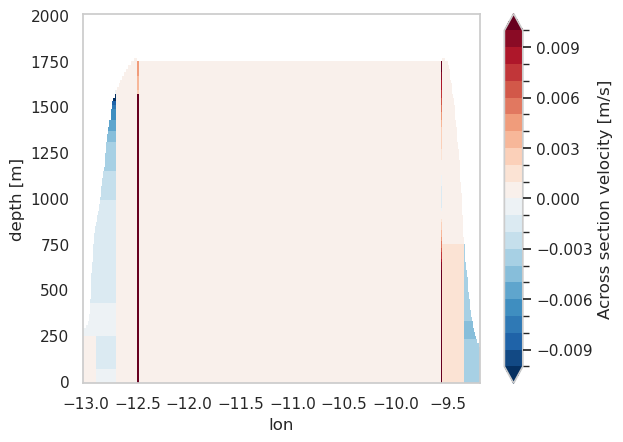

In [40]:
ds_RT_grid.v.mean('TIME').diff('lon').plot(levels=np.arange(-0.01,0.0101,0.001))

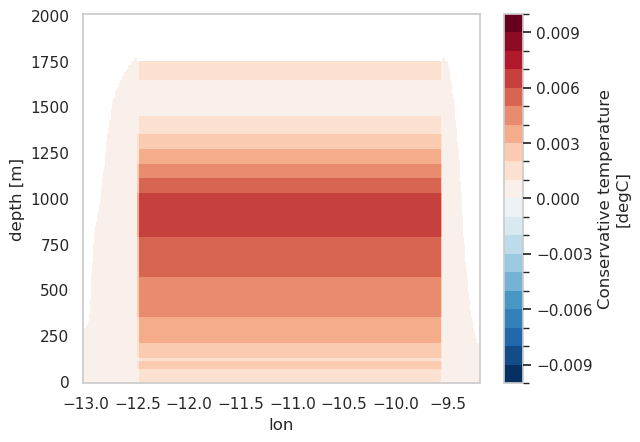

In [41]:
ds_RT_grid.CT.mean('TIME').diff('lon').plot(levels=np.arange(-0.01,0.0101,0.001))

In [42]:
ds_RT_grid

<xarray.Dataset> Size: 11GB
Dimensions:  (lon: 299, depth: 101, TIME: 7279)
Coordinates:
  * lon      (lon) float64 2kB -13.03 -13.03 -13.02 ... -9.2 -9.197 -9.193
    PRES     (depth) float64 808B ...
  * depth    (depth) float32 404B 0.0 20.0 40.0 60.0 ... 1.96e+03 1.98e+03 2e+03
  * TIME     (TIME) datetime64[ns] 58kB 2014-07-21T12:00:00 ... 2024-07-07T12...
    lat      (lon) float64 2kB ...
    dx       (lon) float64 2kB ...
    mask     (lon, depth, TIME) bool 220MB ...
Data variables:
    q        (lon, depth, TIME) float64 2GB ...
    v        (TIME, depth, lon) float64 2GB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    CT       (TIME, depth, lon) float64 2GB 10.22 10.22 10.22 ... nan nan nan
    SA       (TIME, depth, lon) float64 2GB ...
    qh       (lon, depth, TIME) float64 2GB ...
    qf       (lon, depth, TIME) float64 2GB ...
    bathy    (lon) float64 2kB ...
Attributes: (12/19)
    title:                Rockall Trough volume, heat and freshwater transpor...
    institution:          Scottish Association for Marine Science, Scottish M...
    history:              Delayed time processed quality controlled
    description:          Rockall Trough volume, heat and freshwater transpor...
    id:                   Rockall_Trough_mooring_gridded_TSUV_201407_202407_v1
    pi:                   Stuart Cunningham
    ...                   ...
    time_coverage_start:  2014-07-21 12:00:00 PM
    time_coverage_end:    2024-07-07 12:00:00 PM
    citation:             These data were collected and made freely available...
    acknowledgement:      Funding source: the UK Natural Environment Research...
    date_created:         2025-05-08 12:01:00 PM
    date_modified:        2025-05-08 12:01:00 PM

In [43]:
ds_q_RTEW = ds_RT_grid.sel(lon=slice(ds_RT_loc.lon_RTEB.values,None))
ds_q_RTWW = ds_RT_grid.sel(lon=slice(None,ds_RT_loc.lon_RTWB.values))
ds_q_RTMB = ds_RT_grid.sel(lon=slice(ds_RT_loc.lon_RTWB.values+0.01,ds_RT_loc.lon_RTEB.values-0.01))

## Rockall Trough Volume Transport

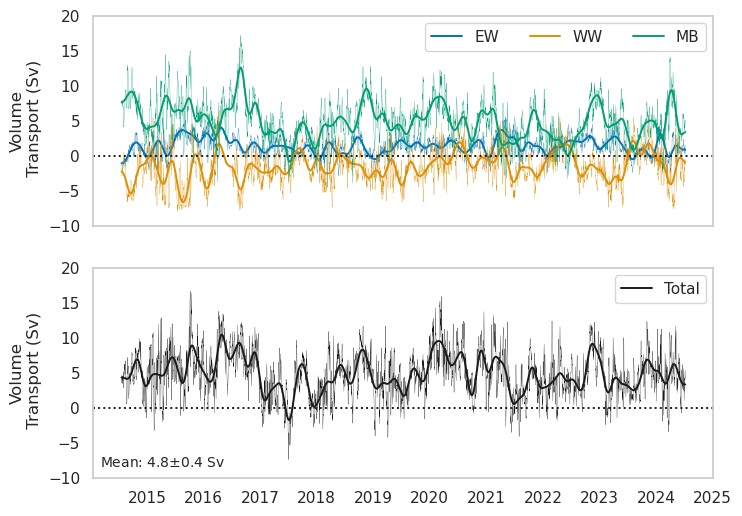

In [44]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=[8,6])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .05

ax=axs[0]
ds_Q_Qh_Qf.Q_EW.plot.line(ax=ax,linewidth=.2,color='C0')
ds_Q_Qh_Qf.Q_lp_EW.plot.line(ax=ax,color='C0',label='EW')

ds_Q_Qh_Qf.Q_WW.plot.line(ax=ax,linewidth=.2,color='C1')
ds_Q_Qh_Qf.Q_lp_WW.plot.line(ax=ax,color='C1',label='WW')

ds_Q_Qh_Qf.Q_MB.plot.line(ax=ax,linewidth=.2,color='C2')
ds_Q_Qh_Qf.Q_lp_MB.plot.line(ax=ax,color='C2',label='MB')


ax=axs[1]
ds_Q_Qh_Qf.Q_total.plot.line('k',ax=ax,linewidth=.2)
ds_Q_Qh_Qf.Q_total_lp.plot.line('k',ax=ax,label='Total')
ax.text(left, bottom, 
        (r'Mean: %2.1f$\pm$%2.1f Sv' %(ds_Q_Qh_Qf.Q_total.mean().values,ds_Q_Qh_Qf.Q_total_SE.values)),
        fontsize=10,
        transform=ax.transAxes)


for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[0])
    ax.set_xlabel('')
    ax.legend(ncol = len(ax.lines))
    ax.set_ylim([-10, 20])
    ax.axhline(0,color='k',ls=':')

fig.savefig(fig_out_path/f'Rockall_Trough_volume_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

## Rockall Trough Heat Transport

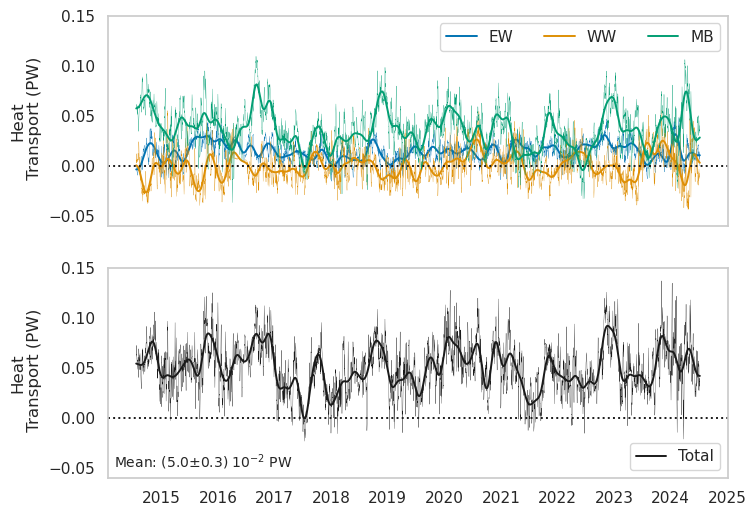

In [45]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=[8,6])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .05

ax=axs[0]
ds_Q_Qh_Qf.Qh_EW.plot.line(ax=ax,linewidth=.2,color='C0')
ds_Q_Qh_Qf.Qh_lp_EW.plot.line(ax=ax,color='C0',label='EW')

ds_Q_Qh_Qf.Qh_WW.plot.line(ax=ax,linewidth=.2,color='C1')
ds_Q_Qh_Qf.Qh_lp_WW.plot.line(ax=ax,color='C1',label='WW')

ds_Q_Qh_Qf.Qh_MB.plot.line(ax=ax,linewidth=.2,color='C2')
ds_Q_Qh_Qf.Qh_lp_MB.plot.line(ax=ax,color='C2',label='MB')


ax=axs[1]
ds_Q_Qh_Qf.Qh_total.plot.line('k',ax=ax,linewidth=.2)
ds_Q_Qh_Qf.Qh_total_lp.plot.line('k',ax=ax,label='Total')
ax.text(left, bottom, (r'Mean: (%2.1f$\pm$%2.1f) 10$^{-2}$ PW' %(ds_Q_Qh_Qf.Qh_total.mean().values*1e2,ds_Q_Qh_Qf.Qh_total_SE.values*1e2)),
        fontsize=10,
        transform=ax.transAxes)


for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[1])
    ax.set_xlabel('')
    ax.legend(ncol = len(ax.lines))
    ax.set_ylim([-.06, .15])
    ax.axhline(0,color='k',ls=':')

fig.savefig(fig_out_path/f'Rockall_Trough_heat_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

## Rockall Trough Freshwater Transport

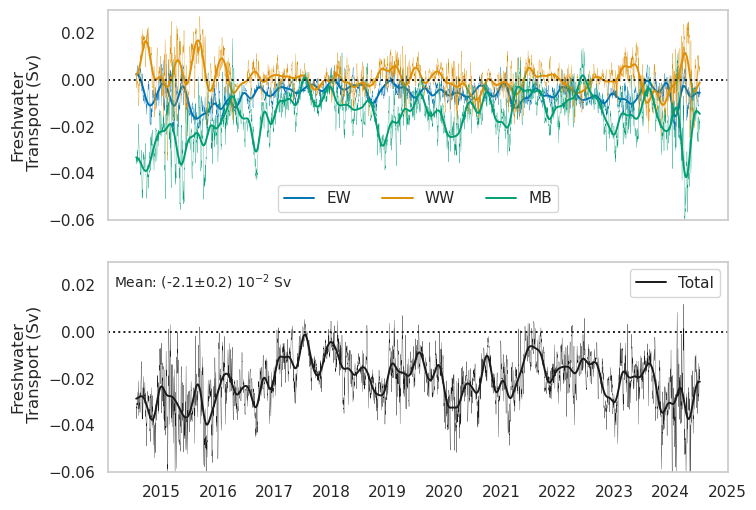

In [46]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=[8,6])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .95

ax=axs[0]
ds_Q_Qh_Qf.Qf_EW.plot.line(ax=ax,linewidth=.2,color='C0')
ds_Q_Qh_Qf.Qf_lp_EW.plot.line(ax=ax,color='C0',label='EW')

ds_Q_Qh_Qf.Qf_WW.plot.line(ax=ax,linewidth=.2,color='C1')
ds_Q_Qh_Qf.Qf_lp_WW.plot.line(ax=ax,color='C1',label='WW')

ds_Q_Qh_Qf.Qf_MB.plot.line(ax=ax,linewidth=.2,color='C2')
ds_Q_Qh_Qf.Qf_lp_MB.plot.line(ax=ax,color='C2',label='MB')


ax=axs[1]
ds_Q_Qh_Qf.Qf_total.plot.line('k',ax=ax,linewidth=.2)
ds_Q_Qh_Qf.Qf_total_lp.plot.line('k',ax=ax,label='Total')
ax.text(left, bottom,(r'Mean: (%2.1f$\pm$%2.1f) 10$^{-2}$ Sv' %(ds_Q_Qh_Qf.Qf_total.mean().values*1e2,ds_Q_Qh_Qf.Qf_total_SE.values*1e2)),
        fontsize=10,va='top',
        transform=ax.transAxes)


for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[2])
    ax.set_xlabel('')
    ax.legend(ncol = len(ax.lines))
    ax.set_ylim([-.06, .03])
    ax.axhline(0,color='k',ls=':')

fig.savefig(fig_out_path/f'Rockall_Trough_freshwater_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

## Rockall Trough Total Transport Timeseries

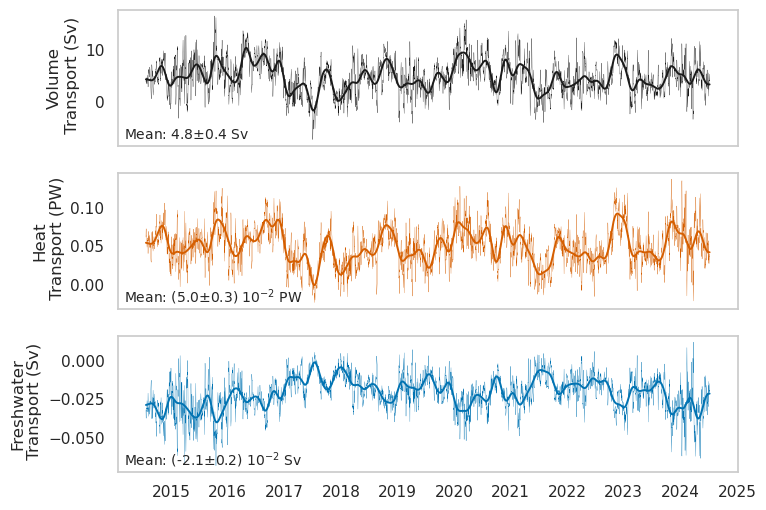

In [47]:
fig,axs = plt.subplots(3,1,sharex=True,figsize=[8,6])

ylabel_name = ['Volume\n Transport (Sv)','Heat\n Transport (PW)','Freshwater\n Transport (Sv)']
# build a rectangle in axes coords
left = .01
bottom = .05

# print(SE.values)
# print(SEh.values)
# print(SEf.values) Q_MB_grid

ds_Q_Qh_Qf.Q_total.plot.line('k',ax=axs[0],linewidth=.2)
ds_Q_Qh_Qf.Q_total_lp.plot.line('k',ax=axs[0],)
axs[0].text(left, bottom, (r'Mean: %2.1f$\pm$%2.1f Sv' %(ds_Q_Qh_Qf.Q_total.mean().values,ds_Q_Qh_Qf.Q_total_SE.values)),
        fontsize=10,
        transform=axs[0].transAxes)

ds_Q_Qh_Qf.Qh_total.plot.line('r',ax=axs[1],linewidth=.2)
ds_Q_Qh_Qf.Qh_total_lp.plot.line('r',ax=axs[1],)
axs[1].text(left, bottom, (r'Mean: (%2.1f$\pm$%2.1f) 10$^{-2}$ PW' %(ds_Q_Qh_Qf.Qh_total.mean().values*1e2,ds_Q_Qh_Qf.Qh_total_SE.values*1e2)),
        fontsize=10,
        transform=axs[1].transAxes)

ds_Q_Qh_Qf.Qf_total.plot.line('b',ax=axs[2],linewidth=.2)
ds_Q_Qh_Qf.Qf_total_lp.plot.line('b',ax=axs[2],)
axs[2].text(left, bottom, (r'Mean: (%2.1f$\pm$%2.1f) 10$^{-2}$ Sv' %(ds_Q_Qh_Qf.Qf_total.mean().values*1e2,ds_Q_Qh_Qf.Qf_total_SE.values*1e2)),
        fontsize=10,
        transform=axs[2].transAxes)

for i,ax in enumerate(axs):
    ax.grid()
    ax.set_title('')
    ax.set_ylabel(ylabel_name[i])
    ax.set_xlabel('')

fig.savefig(fig_out_path/f'Rockall_Trough_total_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

## Rockall Trough Mean Sections

In [48]:
ds_RT_grid = rtf.calc_sigma0_grid(ds_RT_grid)

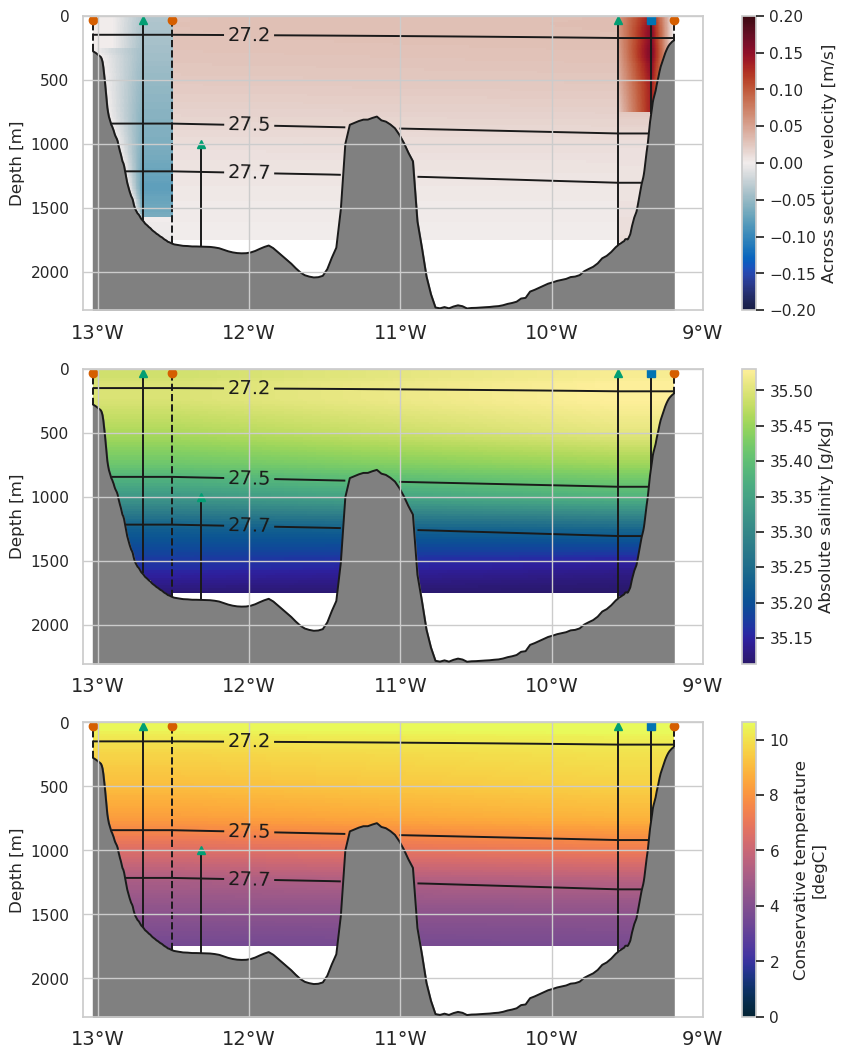

In [49]:
## figure
plt.rcParams.update({'font.size': 14})

xticks = np.arange(-13.,-8,1)
xticklabels = ['13°W','12°W','11°W','10°W','9°W']

sigma_contours = [27.2,27.5, 27.7]
manual_locations = [(-12,100),(-12,900),(-12,1250)]

# Set up figure
fig,axs = plt.subplots(3,1,figsize=[10,13])

ds_RT_grid.v.mean('TIME',keep_attrs=True).plot(
            ax=axs[0],y='depth',x='lon',yincrease=False,cmap=cm.cm.balance,vmin=-0.2,vmax=0.2)
ds_RT_grid.SA.mean('TIME',keep_attrs=True).plot(
            ax=axs[1],y='depth',x='lon',yincrease=False,cmap=cm.cm.haline)
ds_RT_grid.CT.mean('TIME',keep_attrs=True).plot(
            ax=axs[2],y='depth',x='lon',yincrease=False,cmap=cm.cm.thermal,vmin=0)

for ax in axs:
    ax.fill_between(ds_RT_grid.lon, -ds_RT_grid.bathy,2300,color='grey')
    (-ds_RT_grid.bathy).plot.line('k',ax=ax)
    CS = ds_RT_grid.sigma0.mean('TIME',keep_attrs=True).where(ds_RT_grid.depth<=-ds_RT_grid.bathy).plot.contour(
        ax=ax,x='lon',levels=sigma_contours,yincrease=False,colors='k')
    ax.clabel(CS,manual=manual_locations)
    
    ax.vlines(ds_RT_loc.lon_RTWB,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTWB,method='nearest'), 0,colors='k',ls='--')
    ax.vlines(ds_RT_loc.lon_RTES,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTES,method='nearest'), 0,colors='k',ls='--')
    ax.vlines(ds_RT_loc.lon_RTWS,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTWS,method='nearest'), 0,colors='k',ls='--')
    
    ax.vlines(ds_RT_loc.lon_RTADCP,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTADCP,method='nearest'), 0,colors='k')
    ax.vlines(ds_RT_loc.lon_RTEB,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTEB,method='nearest'), 50,colors='k')
    ax.vlines(ds_RT_loc.lon_RTWB1,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTWB1,method='nearest'), 50,colors='k')
    ax.vlines(ds_RT_loc.lon_RTWB2,-ds_RT_grid.bathy.sel(lon=ds_RT_loc.lon_RTWB2,method='nearest'), 1000,colors='k')
    
    d= 30.
    ax.plot([ds_RT_loc.lon_RTES,ds_RT_loc.lon_RTWS,ds_RT_loc.lon_RTWB],[d,d,d],'or')
    ax.plot([ds_RT_loc.lon_RTADCP],[d],'sb')
    ax.plot([ds_RT_loc.lon_RTEB,ds_RT_loc.lon_RTWB1],[d,d],'^g')
    ax.plot([ds_RT_loc.lon_RTWB2],[1000],'^g')
    
    ax.set_xlim([-13.1,-9.])
    ax.set_xlabel('')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels,fontsize=14)
    ax.grid()

    ax.set_ylabel('Depth [m]')
    ax.set_ylim([2300,0])

fig.savefig(fig_out_path/f'Rockall_Trough_mean_sections_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

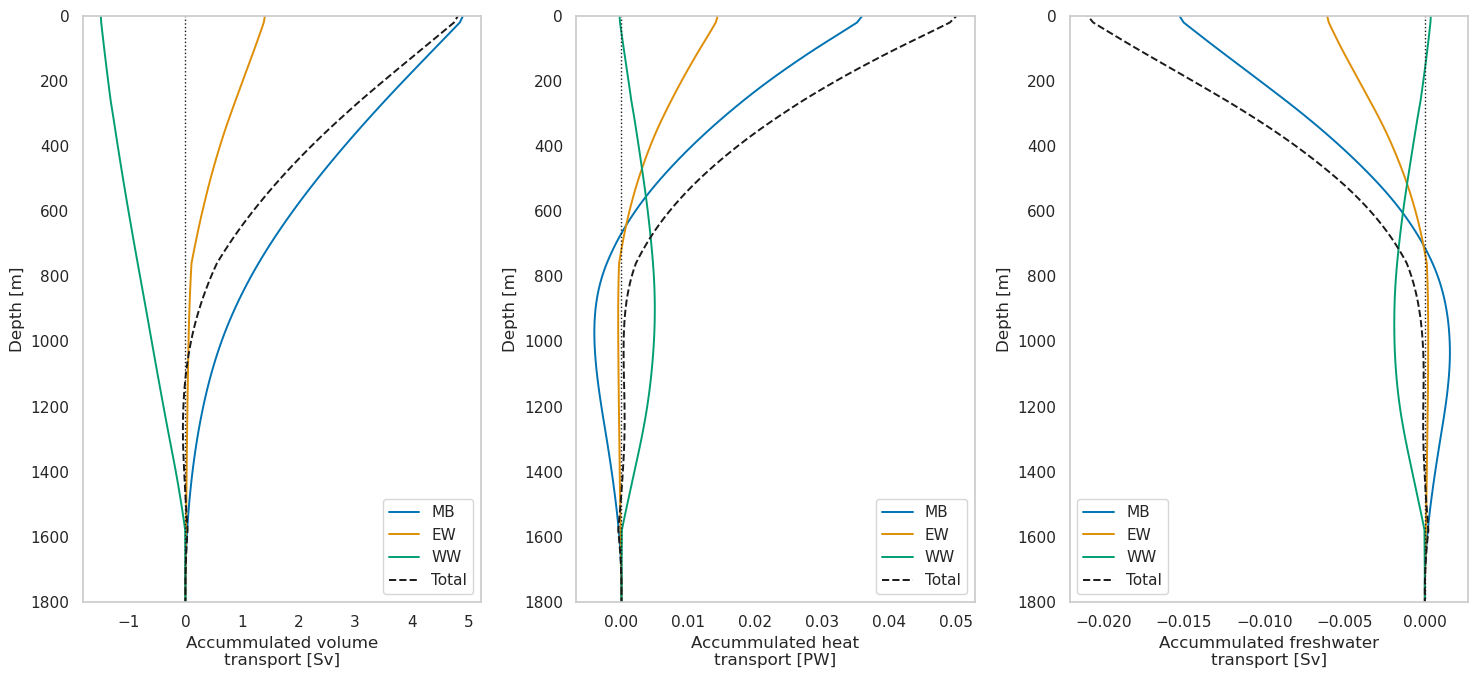

In [50]:


fig,axs = plt.subplots(1,3,figsize=[15,7])
ax=axs[0]
(ds_q_RTMB.q.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTMB.depth[::-1]).cumsum('depth').plot(y='depth',ylim=[1800,0],label='MB',ax=ax)
(ds_q_RTEW.q.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTEW.depth[::-1]).cumsum('depth').plot(y='depth',label='EW',ax=ax)
(ds_q_RTWW.q.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTWW.depth[::-1]).cumsum('depth').plot(y='depth',label='WW',ax=ax)
(ds_RT_grid.q.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_RT_grid.depth[::-1]).cumsum('depth').plot(y='depth',label='Total',color='k',ls='--',ax=ax)
ax.set_xlabel('Accummulated volume\ntransport [Sv]')

ax=axs[1]
(ds_q_RTMB.qh.sum('lon')/1e15).mean(['TIME']).reindex(depth=ds_q_RTMB.depth[::-1]).cumsum('depth').plot(y='depth',ylim=[1800,0],label='MB',ax=ax)
(ds_q_RTEW.qh.sum('lon')/1e15).mean(['TIME']).reindex(depth=ds_q_RTEW.depth[::-1]).cumsum('depth').plot(y='depth',label='EW',ax=ax)
(ds_q_RTWW.qh.sum('lon')/1e15).mean(['TIME']).reindex(depth=ds_q_RTWW.depth[::-1]).cumsum('depth').plot(y='depth',label='WW',ax=ax)
(ds_RT_grid.qh.sum('lon')/1e15).mean(['TIME']).reindex(depth=ds_RT_grid.depth[::-1]).cumsum('depth').plot(y='depth',label='Total',color='k',ls='--',ax=ax)
ax.set_xlabel('Accummulated heat\ntransport [PW]')

ax=axs[2]
(ds_q_RTMB.qf.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTMB.depth[::-1]).cumsum('depth').plot(y='depth',ylim=[1800,0],label='MB',ax=ax)
(ds_q_RTEW.qf.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTEW.depth[::-1]).cumsum('depth').plot(y='depth',label='EW',ax=ax)
(ds_q_RTWW.qf.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_q_RTWW.depth[::-1]).cumsum('depth').plot(y='depth',label='WW',ax=ax)
(ds_RT_grid.qf.sum('lon')/1e6).mean(['TIME']).reindex(depth=ds_RT_grid.depth[::-1]).cumsum('depth').plot(y='depth',label='Total',color='k',ls='--',ax=ax)
ax.set_xlabel('Accummulated freshwater\ntransport [Sv]')


for ax in axs:
    ax.axvline(0,ls=':',color='k',lw='1')
    ax.legend()
    ax.set_ylabel('Depth [m]')
    ax.grid()
    ax.set_title('')
plt.tight_layout()

fig.savefig(fig_out_path/f'Rockall_Trough_depth_accumulated_mean_transports_{date_str_start}_{date_str_end}_{fn_out_version}.png',dpi=300,bbox_inches='tight')

### Build some simple datafiles sum and average in longitude

In [51]:
ds_q_RTEW_1 = ds_q_RTEW.copy(deep=True)
ds_q_RTWW_1 = ds_q_RTWW.copy(deep=True)
ds_q_RTMB_1 = ds_q_RTMB.copy(deep=True)



#### sum the transports

In [52]:
ds_q_RTEW_1["EW_q"] = ds_q_RTEW_1.q.sum('lon')*1.0e-06
ds_q_RTEW_1["EW_qh"] = ds_q_RTEW_1.qh.sum('lon')*1.0e-15
ds_q_RTEW_1["EW_qf"] = ds_q_RTEW_1.qf.sum('lon')*1.0e-06

ds_q_RTWW_1["WW_q"] = ds_q_RTWW_1.q.sum('lon')*1.0e-06
ds_q_RTWW_1["WW_qh"] = ds_q_RTWW_1.qh.sum('lon')*1.0e-15
ds_q_RTWW_1["WW_qf"] = ds_q_RTWW_1.qf.sum('lon')*1.0e-06

ds_q_RTMB_1["MB_q"] = ds_q_RTMB_1.q.sum('lon')*1.0e-06
ds_q_RTMB_1["MB_qh"] = ds_q_RTMB_1.qh.sum('lon')*1.0e-15
ds_q_RTMB_1["MB_qf"] = ds_q_RTMB_1.qf.sum('lon')*1.0e-06



#### area-average the T,S,v

In [53]:
ds_q_RTEW_1["EW_CT"] = (((ds_q_RTEW_1.CT * ds_q_RTEW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTEW_1.CT.notnull() * ds_q_RTEW_1.dx).sum('lon',skipna=True)))
ds_q_RTEW_1["EW_SA"] = (((ds_q_RTEW_1.SA * ds_q_RTEW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTEW_1.SA.notnull() * ds_q_RTEW_1.dx).sum('lon',skipna=True)))
ds_q_RTEW_1["EW_v"] = (((ds_q_RTEW_1.v * ds_q_RTEW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTEW_1.v.notnull() * ds_q_RTEW_1.dx).sum('lon')))

ds_q_RTWW_1["WW_CT"] = (((ds_q_RTWW_1.CT * ds_q_RTWW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTWW_1.CT.notnull() * ds_q_RTWW_1.dx).sum('lon',skipna=True)))
ds_q_RTWW_1["WW_SA"] = (((ds_q_RTWW_1.SA * ds_q_RTWW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTWW_1.SA.notnull() * ds_q_RTWW_1.dx).sum('lon',skipna=True)))
ds_q_RTWW_1["WW_v"] = (((ds_q_RTWW_1.v * ds_q_RTWW_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTWW_1.v.notnull() * ds_q_RTWW_1.dx).sum('lon')))

ds_q_RTMB_1["MB_CT"] = (((ds_q_RTMB_1.CT * ds_q_RTMB_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTMB_1.CT.notnull() * ds_q_RTMB_1.dx).sum('lon',skipna=True)))
ds_q_RTMB_1["MB_SA"] = (((ds_q_RTMB_1.SA * ds_q_RTMB_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTMB_1.SA.notnull() * ds_q_RTMB_1.dx).sum('lon',skipna=True)))
ds_q_RTMB_1["MB_v"] = (((ds_q_RTMB_1.v * ds_q_RTMB_1.dx).sum('lon',skipna=True)) / 
                     ((ds_q_RTMB_1.v.notnull() * ds_q_RTMB_1.dx).sum('lon')))



#### tidy up

In [54]:
ds_q_RTEW_1["EW_dx"] = ((ds_q_RTEW_1.CT.notnull() * ds_q_RTEW_1.dx).sum('lon',skipna=True))
ds_q_RTWW_1["WW_dx"] = ((ds_q_RTWW_1.CT.notnull() * ds_q_RTWW_1.dx).sum('lon',skipna=True))
ds_q_RTMB_1["MB_dx"] = ((ds_q_RTMB_1.CT.notnull() * ds_q_RTMB_1.dx).sum('lon',skipna=True))


In [55]:
ds_q_RTEW_1 = ds_q_RTEW_1.drop_vars(["q","qh","qf","CT","SA","v","bathy","mask","lat"])
ds_q_RTWW_1 = ds_q_RTWW_1.drop_vars(["q","qh","qf","CT","SA","v","bathy","mask","lat"])
ds_q_RTMB_1 = ds_q_RTMB_1.drop_vars(["q","qh","qf","CT","SA","v","bathy","mask","lat"])
ds_q_RTEW_1 = ds_q_RTEW_1.drop_vars(["lon"])
ds_q_RTWW_1 = ds_q_RTWW_1.drop_vars(["lon"])
ds_q_RTMB_1 = ds_q_RTMB_1.drop_vars(["lon"])

In [56]:
ds_q_RTEW_1 = ds_q_RTEW_1.drop_dims(["lon"])
ds_q_RTWW_1 = ds_q_RTWW_1.drop_dims(["lon"])
ds_q_RTMB_1 = ds_q_RTMB_1.drop_dims(["lon"])

In [57]:
ds_q_RTEW_1["EW_dx"] = ds_q_RTEW_1.EW_dx.mean('TIME').assign_attrs(units = 'm',long_name = 'length',description='horizontal length of section')
ds_q_RTWW_1["WW_dx"] = ds_q_RTWW_1.WW_dx.mean('TIME').assign_attrs(units = 'm',long_name = 'length',description='horizontal length of section')
ds_q_RTMB_1["MB_dx"] = ds_q_RTMB_1.MB_dx.mean('TIME').assign_attrs(units = 'm',long_name = 'length',description='horizontal length of section')


In [58]:
ds_q_RT_1 = ds_q_RTEW_1.merge(ds_q_RTWW_1)

In [59]:
ds_q_RT_1 = ds_q_RT_1.merge(ds_q_RTMB_1)

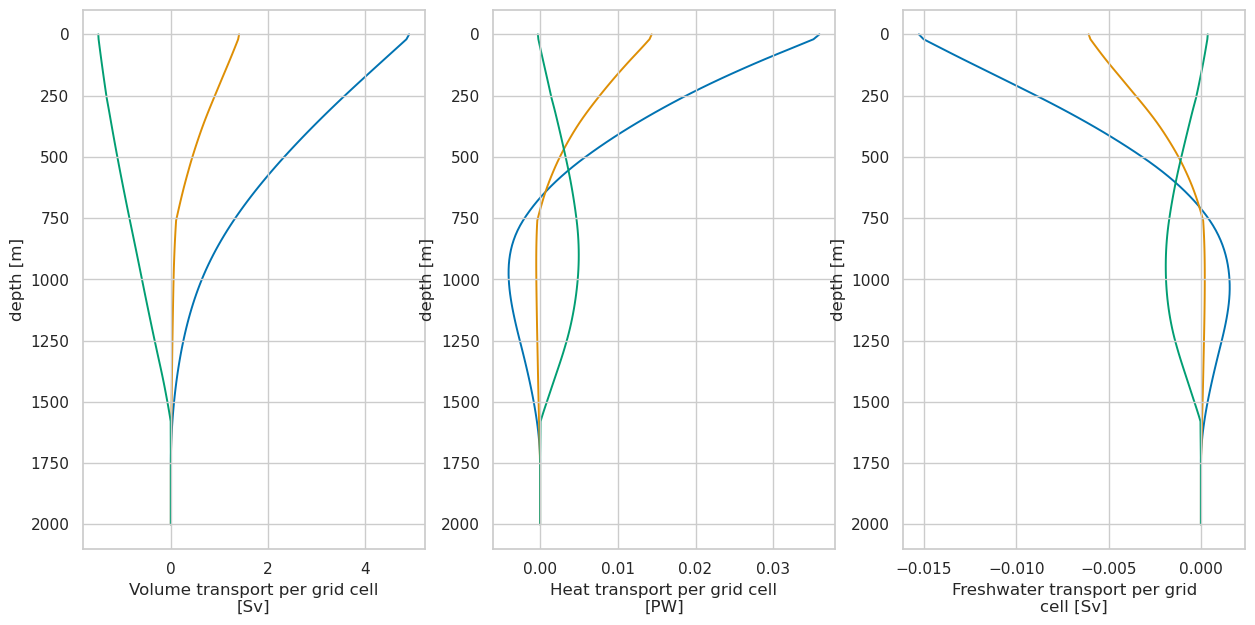

In [60]:
fig,axs = plt.subplots(1,3,figsize=[15,7])

ax=axs[0]
ds_q_RT_1.MB_q.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.EW_q.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.WW_q.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ax.invert_yaxis()
ax=axs[1]
ds_q_RT_1.MB_qh.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.EW_qh.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.WW_qh.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ax.invert_yaxis()
ax=axs[2]
ds_q_RT_1.MB_qf.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.EW_qf.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ds_q_RT_1.WW_qf.mean('TIME')[::-1].cumsum().plot(ax=ax,y='depth')
ax.invert_yaxis()


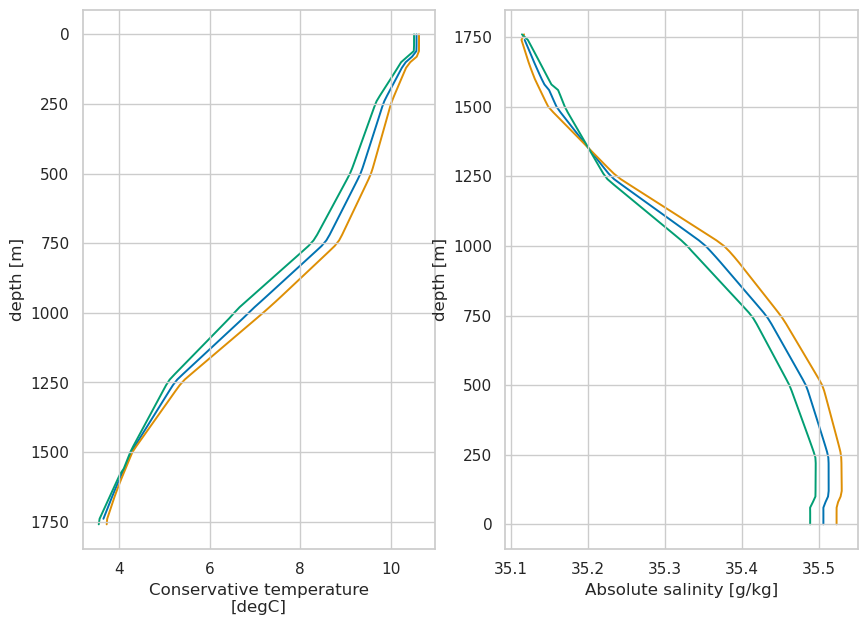

In [61]:
fig,axs = plt.subplots(1,2,figsize=[10,7])

ax=axs[0]
ds_q_RT_1.MB_CT.mean('TIME').plot(ax=ax,y='depth')
ds_q_RT_1.EW_CT.mean('TIME').plot(ax=ax,y='depth')
ds_q_RT_1.WW_CT.mean('TIME').plot(ax=ax,y='depth')
ax.invert_yaxis()
ax=axs[1]
ds_q_RT_1.MB_SA.mean('TIME').plot(ax=ax,y='depth')
ds_q_RT_1.EW_SA.mean('TIME').plot(ax=ax,y='depth')
ds_q_RT_1.WW_SA.mean('TIME').plot(ax=ax,y='depth')
ax.invert_yaxis()
ax.invert_yaxis()


In [62]:
ds_q_RT_1

<xarray.Dataset> Size: 106MB
Dimensions:  (depth: 101, TIME: 7279)
Coordinates:
    PRES     (depth) float64 808B 0.0 20.19 40.38 60.57 ... 1.988e+03 nan nan
  * depth    (depth) float32 404B 0.0 20.0 40.0 60.0 ... 1.96e+03 1.98e+03 2e+03
  * TIME     (TIME) datetime64[ns] 58kB 2014-07-21T12:00:00 ... 2024-07-07T12...
Data variables: (12/21)
    EW_q     (depth, TIME) float64 6MB -0.001793 -0.002283 -0.002747 ... 0.0 0.0
    EW_qh    (depth, TIME) float64 6MB -2.401e-05 -3.07e-05 ... 0.0 0.0
    EW_qf    (depth, TIME) float64 6MB 1.201e-05 1.494e-05 1.689e-05 ... 0.0 0.0
    EW_CT    (TIME, depth) float64 6MB 10.34 10.34 10.34 10.34 ... nan nan nan
    EW_SA    (TIME, depth) float64 6MB 35.58 35.58 35.58 35.58 ... nan nan nan
    EW_v     (TIME, depth) float64 6MB -0.008074 -0.008174 -0.009324 ... nan nan
    ...       ...
    MB_qh    (depth, TIME) float64 6MB 0.001108 0.001127 0.001168 ... 0.0 0.0
    MB_qf    (depth, TIME) float64 6MB -0.0005488 -0.0005486 ... 0.0 0.0
    MB_CT    (TIME, depth) float64 6MB 10.28 10.28 10.28 10.28 ... nan nan nan
    MB_SA    (TIME, depth) float64 6MB 35.57 35.57 35.57 35.57 ... nan nan nan
    MB_v     (TIME, depth) float64 6MB 0.04627 0.04618 0.04609 ... nan nan nan
    MB_dx    (depth) float64 808B 1.82e+05 1.82e+05 1.82e+05 ... 0.0 0.0 0.0
Attributes: (12/19)
    title:                Rockall Trough volume, heat and freshwater transpor...
    institution:          Scottish Association for Marine Science, Scottish M...
    history:              Delayed time processed quality controlled
    description:          Rockall Trough volume, heat and freshwater transpor...
    id:                   Rockall_Trough_mooring_gridded_TSUV_201407_202407_v1
    pi:                   Stuart Cunningham
    ...                   ...
    time_coverage_start:  2014-07-21 12:00:00 PM
    time_coverage_end:    2024-07-07 12:00:00 PM
    citation:             These data were collected and made freely available...
    acknowledgement:      Funding source: the UK Natural Environment Research...
    date_created:         2025-05-08 12:01:00 PM
    date_modified:        2025-05-08 12:01:00 PM

In [63]:
ds_q_RT_1.to_netcdf(f'{data_out_path_od}/{file_name_out_profile}')

In [64]:
conda list

# packages in environment at /home/sa05af/.conda/envs/af_python3_12:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                 conda_forge    conda-forge
_openmp_mutex             4.5                       2_gnu    conda-forge
alsa-lib                  1.2.12               h4ab18f5_0    conda-forge
annotated-types           0.7.0              pyhd8ed1ab_1    conda-forge
asciitree                 0.3.3                      py_2    conda-forge
asttokens                 2.4.1              pyhd8ed1ab_0    conda-forge
aws-c-auth                0.7.31               h57bd9a3_0    conda-forge
aws-c-cal                 0.7.4                hfd43aa1_1    conda-forge
aws-c-common              0.9.28               hb9d3cd8_0    conda-forge
aws-c-compression         0.2.19               h756ea98_1    conda-forge
aws-c-event-stream        0.4.3                h29ce20c_2    conda-forge
aws-c-http                0.8.10               h5e77a74_0  